In [1]:
import pandas as pd

fish = pd.read_csv(r'https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fish.csv', low_memory=False)
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']]
fish_target = fish['Species']

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state=42)

from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

from sklearn.linear_model import SGDClassifier
sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

sc.partial_fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))



0.7815126050420168
0.8
0.8067226890756303
0.825


C:\Users\박중현\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


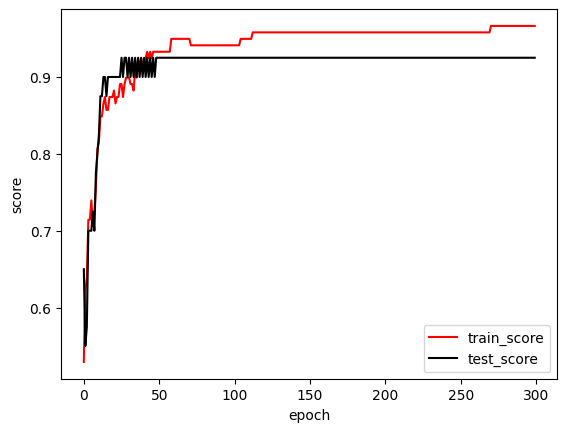

In [2]:
from sklearn.linear_model import SGDClassifier
import numpy as np
sg = SGDClassifier(loss='log_loss', random_state=42)
train_score=[]
test_score=[]
classes = np.unique(train_target)

for _ in range(0, 300):
    sg.partial_fit(train_scaled, train_target, classes=classes)
    train_score.append(sg.score(train_scaled, train_target))
    test_score.append(sg.score(test_scaled, test_target))
    
import matplotlib.pyplot as plt
plt.plot(train_score, c='red', label='train_score')
plt.plot(test_score, c='black', label='test_score')
plt.xlabel('epoch')
plt.ylabel('score')
plt.legend()
plt.show()

In [6]:
sc = SGDClassifier(loss='log_loss', max_iter=100, random_state=42, tol=None)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

sgd = SGDClassifier(loss='hinge', max_iter=100, tol=None, random_state=42)
sgd.fit(train_scaled, train_target)
print(sgd.score(train_scaled, train_target))
print(sgd.score(test_scaled, test_target))
print(sgd.coef_, sgd.intercept_)

0.957983193277311
0.925
0.9495798319327731
0.925
[[ -6.31199733  -1.33552524   7.33649817  13.10673227  -1.71165212]
 [-13.76267623   0.2937716  -20.2824874   20.9769056    2.00093805]
 [ -1.8550808   33.28135484 -39.35261809  -3.78132278   8.98380757]
 [ -0.75138695   6.42365905   6.16013019  -8.27102309  -0.88897892]
 [-12.64830086 -26.32686785  24.42673857  -4.06182659   8.9276778 ]
 [-13.07369872   9.78029868  10.33035437 -27.83727632 -22.46370364]
 [ -4.91661079  -4.35724571   2.33740112  -0.07812776   4.78387488]] [-10.92437021 -20.13970789  -3.17564278 -11.76623826  -6.96920531
 -56.92072076  -4.93629361]
